# Intro

The data from this file is taken from Central Pollution Control Board (CPCB). A script was used to run through the whole website and we took one station from each city that was available on the website and came up with a dataset with over 4,00,000 rows. We also converted the text columns of cities and changed it to latitude and ongitude so that we can use it as a numeric column. This is everything related to the intro of the data

## 1. Importing the libraries

We need to first import all the libraries that we need to use for the dataset

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

MERGED_FILE = "merged_data.csv"

## 2. AQI Calculation Functions

AQI is calculated using the CPCB formula:

$$\text{Sub-Index} = \frac{I_{hi} - I_{lo}}{BP_{hi} - BP_{lo}} \times (C - BP_{lo}) + I_{lo}$$

Where:
- **C** = pollutant concentration (sensor reading)
- **BP** = breakpoint concentration for this AQI range
- **I** = AQI score for this range

Overall AQI = maximum of all individual sub-indices.

In [123]:
# Breakpoint tables: (concentration_low, concentration_high, aqi_low, aqi_high)
BREAKPOINTS = {
    "PM2.5 (\u00b5g/m\u00b3)": [
        (0, 30, 0, 50), (31, 60, 51, 100), (61, 90, 101, 200),
        (91, 120, 201, 300), (121, 250, 301, 400), (250, 500, 401, 500),
    ],
    "PM10 (\u00b5g/m\u00b3)": [
        (0, 50, 0, 50), (51, 100, 51, 100), (101, 250, 101, 200),
        (251, 350, 201, 300), (351, 430, 301, 400), (430, 600, 401, 500),
    ],
    "NO2 (\u00b5g/m\u00b3)": [
        (0, 40, 0, 50), (41, 80, 51, 100), (81, 180, 101, 200),
        (181, 280, 201, 300), (281, 400, 301, 400), (400, 800, 401, 500),
    ],
    "SO2 (\u00b5g/m\u00b3)": [
        (0, 40, 0, 50), (41, 80, 51, 100), (81, 380, 101, 200),
        (381, 800, 201, 300), (801, 1600, 301, 400), (1600, 3200, 401, 500),
    ],
    "CO (mg/m\u00b3)": [
        (0, 1.0, 0, 50), (1.1, 2.0, 51, 100), (2.1, 10.0, 101, 200),
        (10.1, 17.0, 201, 300), (17.1, 34.0, 301, 400), (34.0, 68.0, 401, 500),
    ],
    "Ozone (\u00b5g/m\u00b3)": [
        (0, 50, 0, 50), (51, 100, 51, 100), (101, 168, 101, 200),
        (169, 208, 201, 300), (209, 748, 301, 400), (748, 1500, 401, 500),
    ],
    "NH3 (\u00b5g/m\u00b3)": [
        (0, 200, 0, 50), (201, 400, 51, 100), (401, 800, 101, 200),
        (801, 1200, 201, 300), (1201, 1800, 301, 400), (1800, 3600, 401, 500),
    ],
}


def get_sub_index(concentration, breakpoints):
    """
    Calculate AQI sub-index for a single pollutant.

    Example: PM2.5 = 75 \u00b5g/m\u00b3
        Falls in range (61, 90) \u2192 AQI range (101, 200)
        Sub-index = ((200-101)/(90-61)) \u00d7 (75-61) + 101 = 148.8
    """
    if pd.isna(concentration) or concentration < 0:
        return np.nan

    for c_lo, c_hi, i_lo, i_hi in breakpoints:
        if c_lo <= concentration <= c_hi:
            return ((i_hi - i_lo) / (c_hi - c_lo)) * (concentration - c_lo) + i_lo

    if concentration > breakpoints[-1][1]:
        return 500
    return np.nan


def calculate_aqi_for_row(row):
    """Calculate overall AQI = max sub-index across all 7 pollutants."""
    sub_indices = []
    for column_name, breakpoints in BREAKPOINTS.items():
        if column_name in row.index:
            si = get_sub_index(row[column_name], breakpoints)
            if not pd.isna(si):
                sub_indices.append(si)

    return max(sub_indices) if sub_indices else np.nan

## 3. Load Data

In [124]:
merged = pd.read_csv(MERGED_FILE, low_memory=False)
print(f"{len(merged):,} rows loaded")
print("\nColumns:")
print(merged.columns)
print("\nDescribe:")
merged.head()

406,466 rows loaded

Columns:
Index(['Timestamp', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)',
       'NO2 (µg/m³)', 'NOx (ppb)', 'NH3 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)',
       'Ozone (µg/m³)', 'Benzene (µg/m³)', 'Toluene (µg/m³)', 'Xylene (µg/m³)',
       'O Xylene (µg/m³)', 'Eth-Benzene (µg/m³)', 'MP-Xylene (µg/m³)',
       'AT (°C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'RF (mm)', 'TOT-RF (mm)',
       'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)', 'state', 'city', 'latitude',
       'longitude'],
      dtype='object')

Describe:


,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³),Toluene (µg/m³),Xylene (µg/m³),O Xylene (µg/m³),Eth-Benzene (µg/m³),MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s),state,city,latitude,longitude
0,2020-01-01 00:00:00,58.37,87.01,1.63,11.98,7.70,14.89,17.73,0.76,56.78,0.87,3.15,0.13,NaN,NaN,0.12,26.61,76.82,4.68,84.46,0.00,0.0,70.31,760.79,0.07,Andhra Pradesh,Amaravati,16.494222,80.510586
1,2020-01-02 00:00:00,42.27,65.17,1.69,12.20,7.86,14.58,18.37,0.73,55.47,0.79,2.14,0.11,NaN,NaN,0.12,26.46,79.39,4.82,83.75,0.00,0.0,47.41,761.69,0.08,Andhra Pradesh,Amaravati,16.494222,80.510586
2,2020-01-03 00:00:00,38.47,61.75,1.80,13.68,8.74,14.46,24.69,0.69,42.05,0.76,3.41,0.18,NaN,NaN,0.16,26.67,80.99,3.58,98.53,0.03,2.7,49.53,759.58,0.05,Andhra Pradesh,Amaravati,16.494222,80.510586
3,2020-01-04 00:00:00,23.84,40.12,2.28,18.82,11.86,14.39,19.99,0.64,23.72,0.61,5.46,0.25,NaN,NaN,0.27,25.88,87.03,2.29,86.02,0.00,0.0,31.85,758.02,0.05,Andhra Pradesh,Amaravati,16.494222,80.510586
4,2020-01-05 00:00:00,37.80,56.34,1.65,12.63,8.06,20.78,14.71,0.63,38.99,0.57,1.73,0.13,NaN,NaN,0.11,26.88,80.81,2.68,83.03,0.00,0.0,53.14,758.80,0.06,Andhra Pradesh,Amaravati,16.494222,80.510586


In [125]:

merged.describe()

,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),Benzene (µg/m³),Toluene (µg/m³),Xylene (µg/m³),O Xylene (µg/m³),Eth-Benzene (µg/m³),MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s),latitude,longitude
count,294227.000000,289880.000000,290311.000000,296756.000000,295607.000000,268576.000000,297159.000000,294622.000000,282291.000000,248809.000000,197002.000000,81443.000000,0.0,172868.000000,173650.000000,193513.000000,258614.000000,267657.000000,266713.000000,200932.000000,342762.000000,237326.000000,109217.000000,32266.000000,406466.000000,406466.000000
mean,49.476973,105.654011,11.449994,21.389594,23.502108,22.057345,12.737792,0.807360,30.738343,2.139925,8.445692,1.965344,NaN,2.590996,4.039858,26.453898,65.264269,1.470223,178.059393,0.056255,0.886814,157.916696,806.436467,0.021610,21.968598,79.291354
std,44.003366,78.754860,22.365473,21.275183,26.683765,21.904072,13.745618,0.638580,22.060045,4.159701,16.948582,5.686418,NaN,12.925468,21.917580,5.737976,19.121253,2.226170,68.544492,0.502505,44.442224,140.697660,100.585691,1.466970,6.515690,4.970470
min,0.030000,0.030000,0.010000,0.010000,0.000000,0.010000,0.010000,0.000000,0.010000,0.000000,0.000000,0.000000,NaN,0.010000,0.010000,0.100000,0.010000,0.010000,0.010000,0.000000,-13.600000,0.000000,700.000000,-19.940000,8.488227,70.912489
25%,21.320000,49.660000,2.760000,8.840000,9.420000,8.183177,4.974000,0.430000,15.010000,0.250000,0.815625,0.150000,NaN,0.270000,0.340000,23.140000,52.760000,0.580000,131.730000,0.000000,0.000000,65.385417,738.490000,-0.226328,16.494222,76.112371
50%,36.802083,84.520833,6.160000,16.061615,17.140000,15.970000,8.950000,0.660000,25.900064,0.940000,2.678785,0.633333,NaN,0.890000,1.020000,27.170000,67.880000,1.000000,181.090000,0.000000,0.000000,124.400000,750.000000,0.000000,23.798101,77.513765
75%,63.350000,139.150000,12.030000,27.089931,28.898264,29.350000,15.515313,0.999297,41.500326,2.660000,8.590000,2.020000,NaN,2.250000,2.980000,30.200000,79.620000,1.660000,228.560000,0.000000,0.000000,204.160000,876.610000,0.129427,26.987344,81.833800
max,1000.000000,999.990000,493.915000,497.400000,491.970000,490.970000,197.625000,11.400000,447.400000,464.240000,480.700000,389.290000,NaN,491.510000,499.100000,58.700000,100.000000,50.000000,360.000000,39.250000,25170.600000,1973.392361,1095.650000,20.000000,31.635666,94.639423


## 4. Calculate AQI, Month and Season

In [126]:
merged["Calculated_AQI"] = merged.apply(calculate_aqi_for_row, axis=1)
valid = merged["Calculated_AQI"].notna().sum()
print(f"Valid AQI: {valid:,} / {len(merged):,} ({valid/len(merged)*100:.1f}%)")

Valid AQI: 305,474 / 406,466 (75.2%)


In [127]:
merged["Timestamp"] = pd.to_datetime(merged["Timestamp"], format='mixed', errors="coerce")
merged["month"] = merged["Timestamp"].dt.month

In [128]:
def get_season(month):
    if month in [12, 1, 2]:
        return 1  # Winter
    elif month in [3, 4, 5]:
        return 2  # Summer
    elif month in [6, 7, 8, 9]:
        return 3  # Monsoon
    elif month in [10, 11]:
        return 4  # Post-Monsoon
    else:
        return np.nan

In [129]:
merged["season"] = merged["month"].apply(get_season)
print(f"Temporal features extracted — month range: {merged['month'].min()}-{merged['month'].max()}")
print(f"Season distribution:\n{merged['season'].value_counts().sort_index().to_string()}")

Temporal features extracted — month range: 1-12
Season distribution:
season
1    100579
2    102212
3    135604
4     68071


## 5. Select & Rename Features

In [130]:
final = merged.rename(columns={
    "AT (°C)":    "AT (Temperature)",
    "RH (%)":     "RH (Humidity)",
    "WS (m/s)":   "WS (Wind Speed)",
    "BP (mmHg)":  "BP (Barometric Pressure)",
    "SR (W/mt2)": "SR (Solar Radiation)",
})[["AT (Temperature)", "RH (Humidity)", "WS (Wind Speed)", "BP (Barometric Pressure)", "SR (Solar Radiation)", "latitude", "longitude", "month", "season", "Calculated_AQI"]]

print("Columns:", final.columns.tolist())
print("\nMissing values:")
final.isna().sum()

Columns: ['AT (Temperature)', 'RH (Humidity)', 'WS (Wind Speed)', 'BP (Barometric Pressure)', 'SR (Solar Radiation)', 'latitude', 'longitude', 'month', 'season', 'Calculated_AQI']

Missing values:


AT (Temperature)            212953
RH (Humidity)               147852
WS (Wind Speed)             138809
BP (Barometric Pressure)    297249
SR (Solar Radiation)        169140
latitude                         0
longitude                        0
month                            0
season                           0
Calculated_AQI              100992
dtype: int64

In [131]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406466 entries, 0 to 406465
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AT (Temperature)          193513 non-null  float64
 1   RH (Humidity)             258614 non-null  float64
 2   WS (Wind Speed)           267657 non-null  float64
 3   BP (Barometric Pressure)  109217 non-null  float64
 4   SR (Solar Radiation)      237326 non-null  float64
 5   latitude                  406466 non-null  float64
 6   longitude                 406466 non-null  float64
 7   month                     406466 non-null  int32  
 8   season                    406466 non-null  int64  
 9   Calculated_AQI            305474 non-null  float64
dtypes: float64(8), int32(1), int64(1)
memory usage: 29.5 MB


In [132]:
final.describe()

,AT (Temperature),RH (Humidity),WS (Wind Speed),BP (Barometric Pressure),SR (Solar Radiation),latitude,longitude,month,season,Calculated_AQI
count,193513.000000,258614.000000,267657.000000,109217.000000,237326.000000,406466.000000,406466.000000,406466.000000,406466.000000,305474.000000
mean,26.453898,65.264269,1.470223,806.436467,157.916696,21.968598,79.291354,6.530775,2.421110,112.848443
std,5.737976,19.121253,2.226170,100.585691,140.697660,6.515690,4.970470,3.451006,1.036154,83.354537
min,0.100000,0.010000,0.010000,700.000000,0.000000,8.488227,70.912489,1.000000,1.000000,0.000000
25%,23.140000,52.760000,0.580000,738.490000,65.385417,16.494222,76.112371,4.000000,2.000000,54.811111
50%,27.170000,67.880000,1.000000,750.000000,124.400000,23.798101,77.513765,7.000000,3.000000,88.660000
75%,30.200000,79.620000,1.660000,876.610000,204.160000,26.987344,81.833800,10.000000,3.000000,137.988792
max,58.700000,100.000000,50.000000,1095.650000,1973.392361,31.635666,94.639423,12.000000,4.000000,500.000000


## 6. Exploratory Data Analysis (Pre-Cleaning)

### 6a. Histograms
Visualize the distribution of each feature to check for skewness and identify potential outliers.

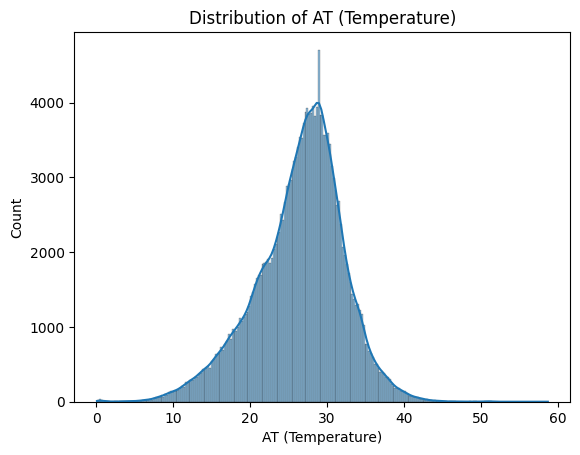

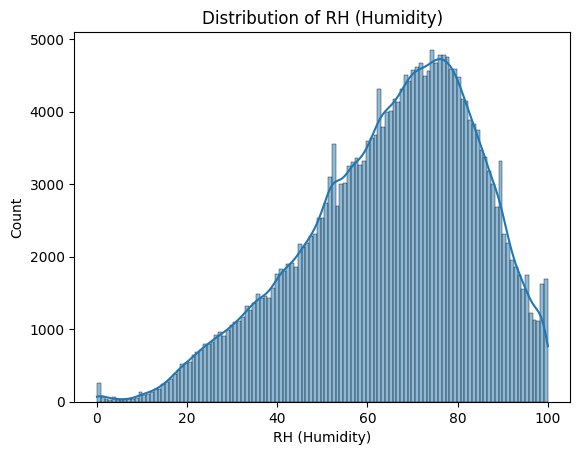

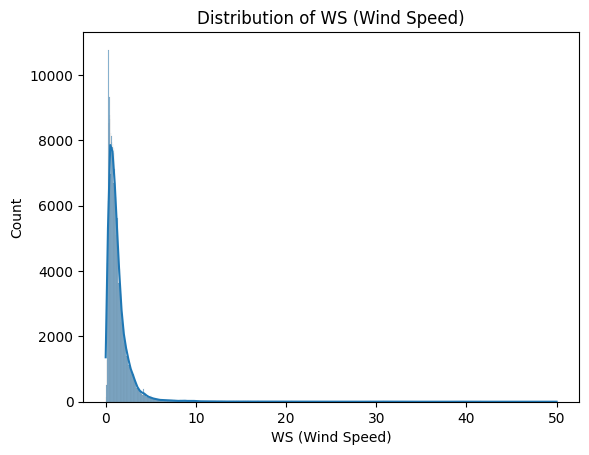

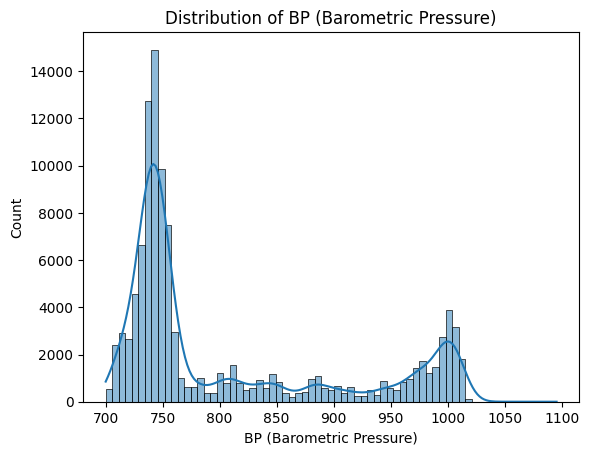

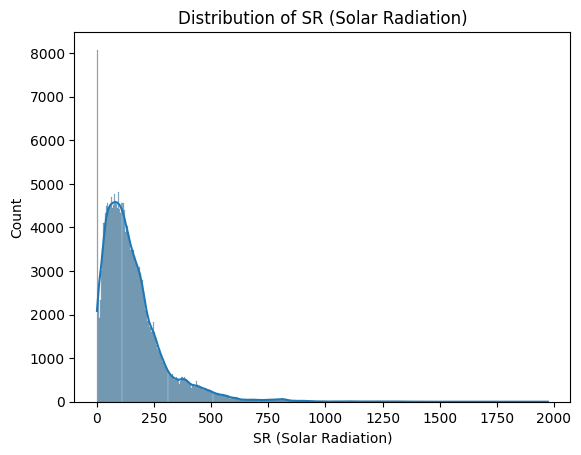

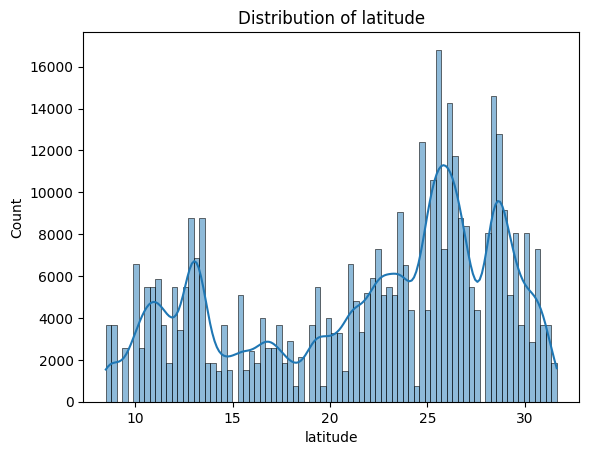

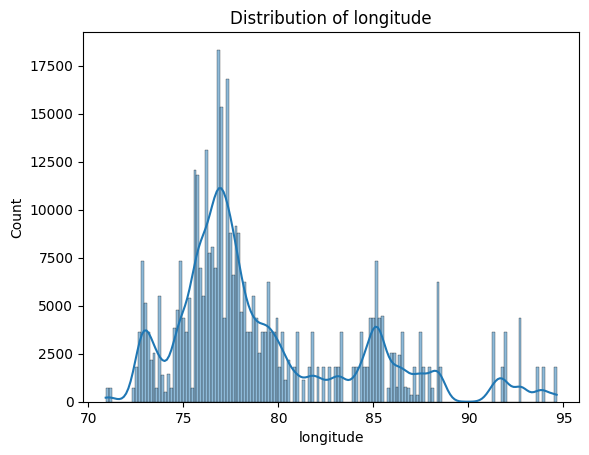

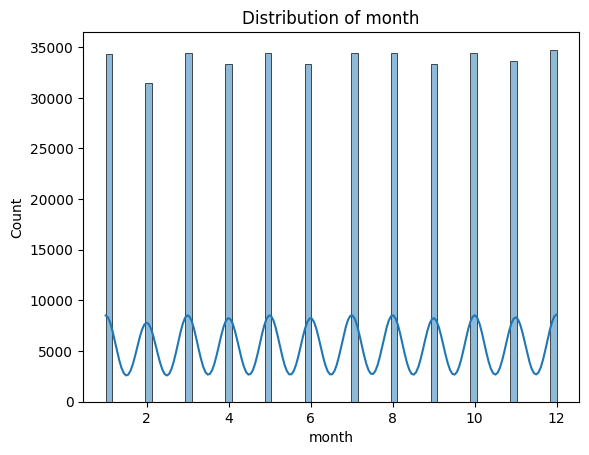

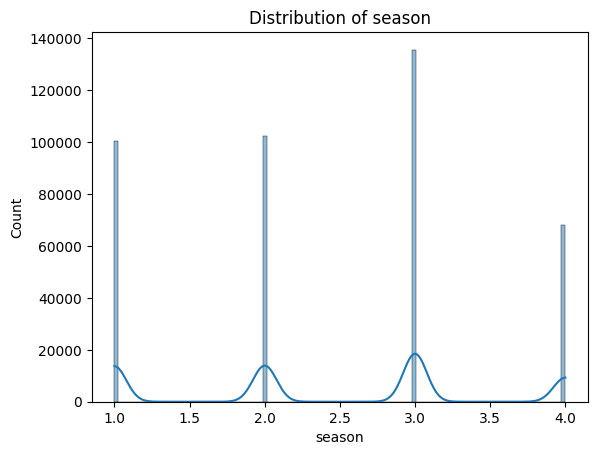

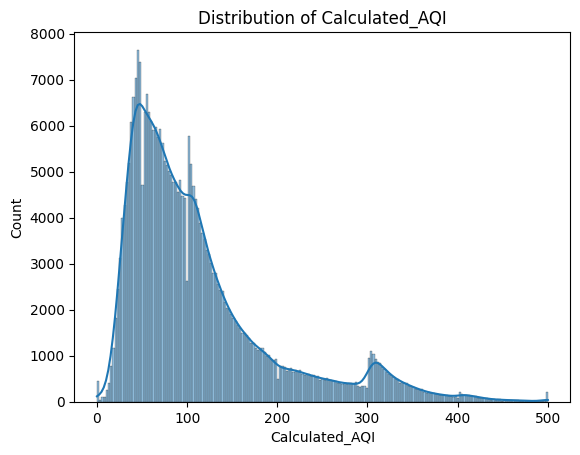

In [133]:
for i in final.columns:
    plt.figure()
    sns.histplot(final[i], kde=True)
    plt.title(f"Distribution of {i}")
    plt.show()

### 6b. Correlation Heatmap
Check how features correlate with each other and with the target (Calculated_AQI).

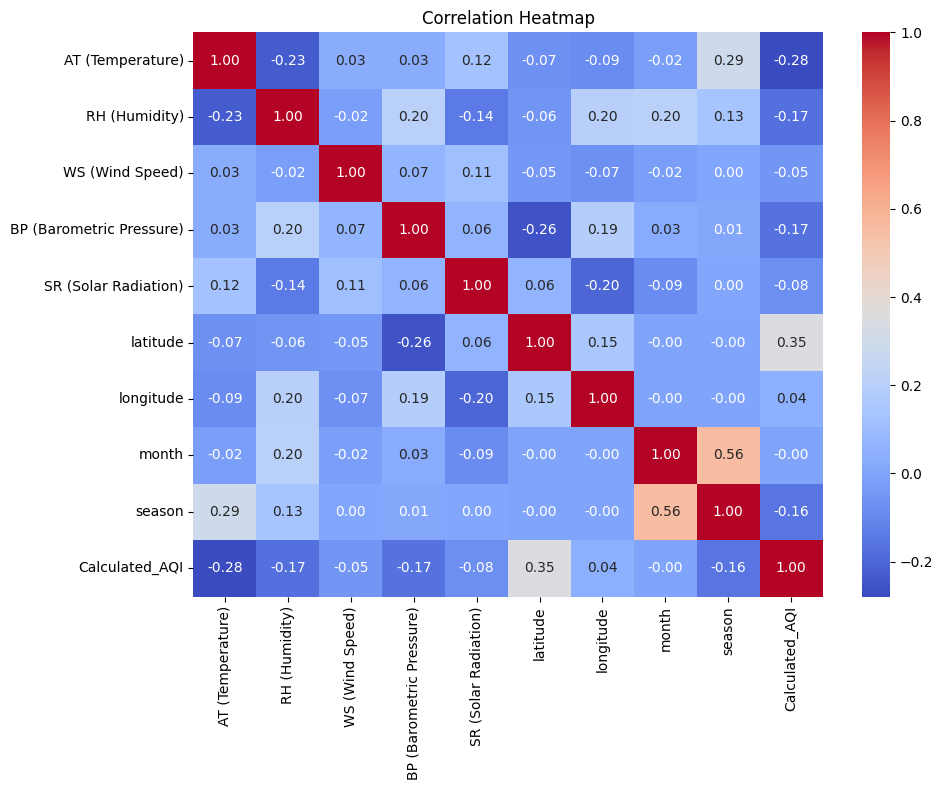

                          AT (Temperature)  ...  Calculated_AQI
AT (Temperature)                  1.000000  ...       -0.279018
RH (Humidity)                    -0.231499  ...       -0.172317
WS (Wind Speed)                   0.029025  ...       -0.052454
BP (Barometric Pressure)          0.028899  ...       -0.165348
SR (Solar Radiation)              0.123560  ...       -0.077955
latitude                         -0.070370  ...        0.349673
longitude                        -0.087478  ...        0.042856
month                            -0.022711  ...       -0.000686
season                            0.294873  ...       -0.158477
Calculated_AQI                   -0.279018  ...        1.000000

[10 rows x 10 columns]


In [134]:
plt.figure(figsize=(10, 8))
sns.heatmap(final.corr(), annot = True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print(final.corr())

### 6c. Boxplots
Identify outliers in each feature using boxplots. Values beyond the whiskers (1.5 * IQR) are potential outliers.

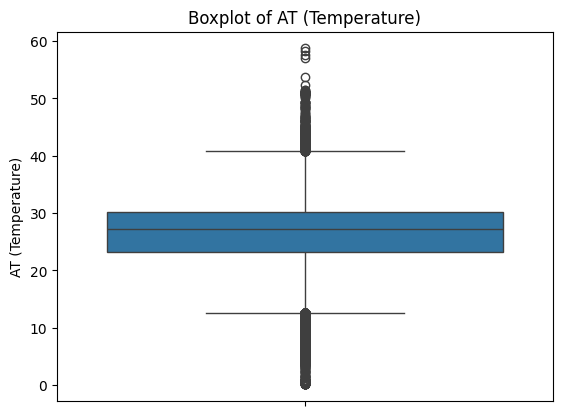

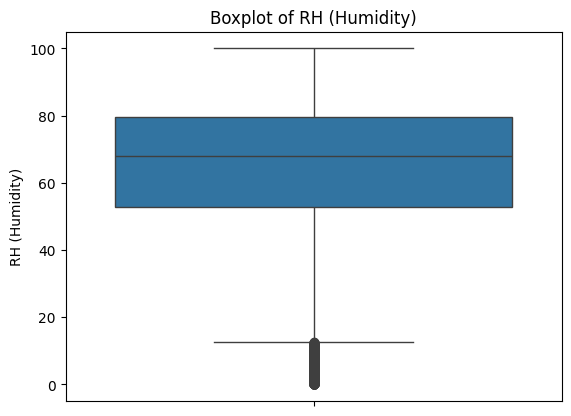

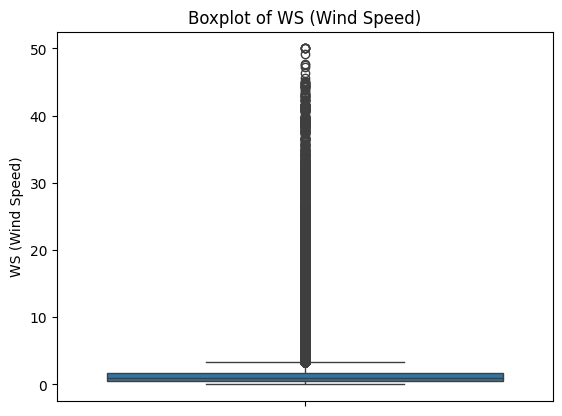

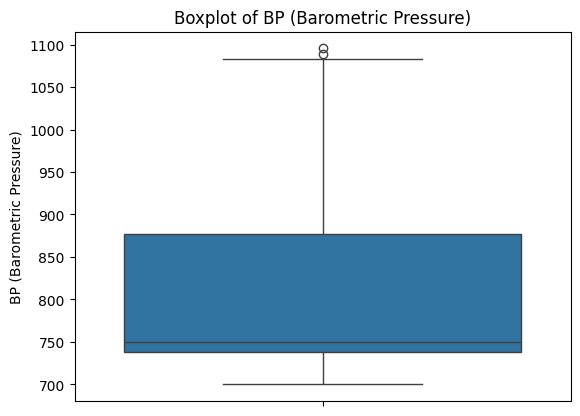

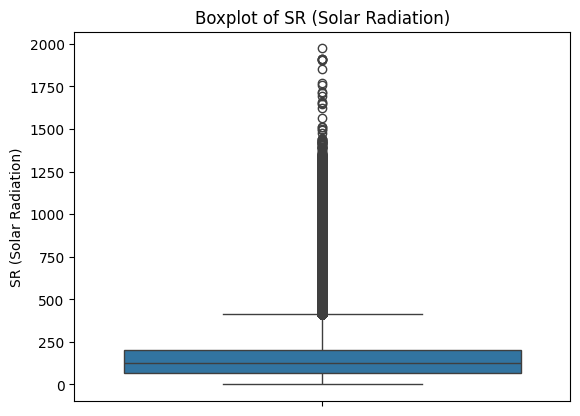

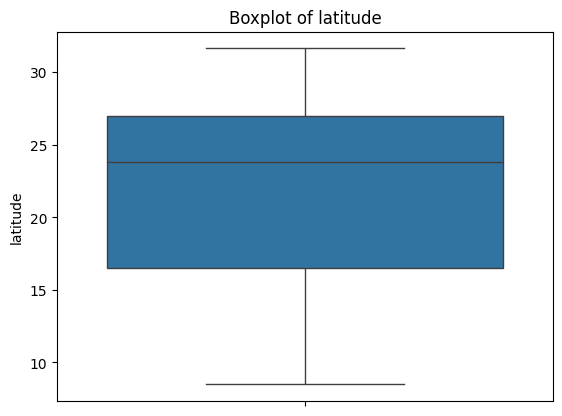

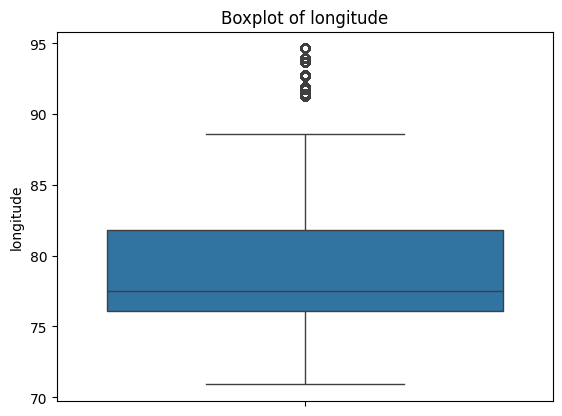

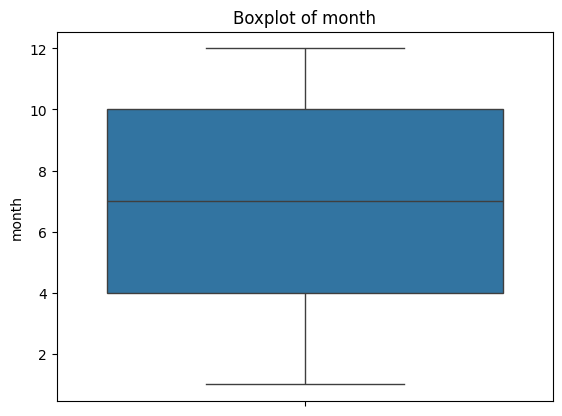

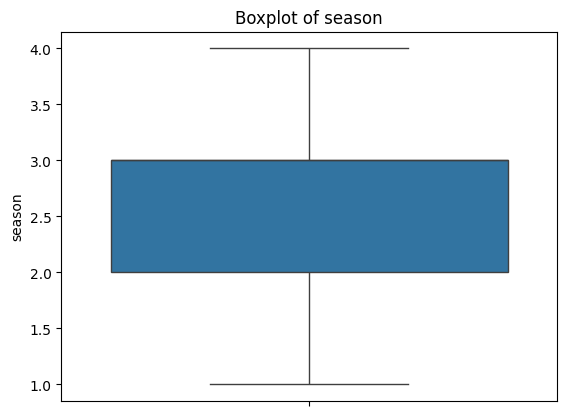

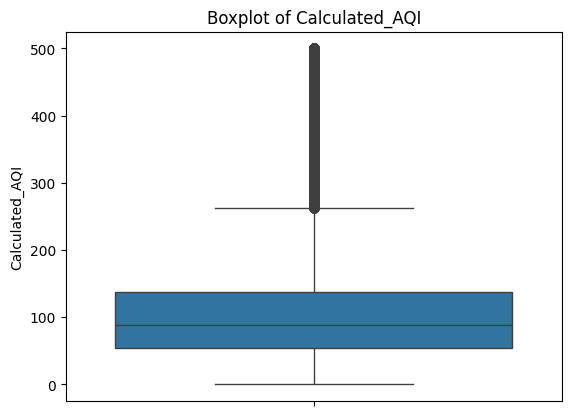

In [135]:
for col in final.columns:
    plt.figure()
    sns.boxplot(y=final[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 7. Data Cleaning

AQI and BP had too many empty values but are important to the dataset (especially AQI), so we are just dropping the remaining columns. Also we thought of dropping the AT rows as well but we found that there was not a major difference between dropping the rows for for AT and just filling the median. So we decided to keep it in there. Also dropping the BP column decreasing the r2 score and increased the MAPE score so it did not make sense to drop them. Hence we are keeping all the columns but just dropping the rows with null values. 

### 7a. Drop rows with missing AQI and BP

In [136]:
before = len(final)
final = final.dropna(subset=["Calculated_AQI"])
print(f"Removed {before - len(final):,} rows with no AQI")

before = len(final)
final = final.dropna(subset=["BP (Barometric Pressure)"])
print(f"Removed {before - len(final):,} rows with no BP")

print(f"\nRemaining rows: {len(final):,}")

Removed 100,992 rows with no AQI
Removed 196,309 rows with no BP

Remaining rows: 109,165


### 7b. Fill missing weather values with Bayesian Ridge



In [137]:
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

print("Starting MICE Imputation on the entire dataset...")

# 1. Temporarily detach the Target Variable so the imputer doesn't "cheat"
target = final['Calculated_AQI']
features_to_impute = final.drop(columns=['Calculated_AQI'])

# 2. Initialize the Imputer
imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)

# 3. Pass the entire feature dataframe in ONE step!
# The imputer handles all the 'temp train/test' and 'y' target switching automatically.
imputed_matrix = imputer.fit_transform(features_to_impute)

# 4. The imputer outputs a raw numpy array. Let's turn it back into a beautifully named Pandas DataFrame.
final = pd.DataFrame(imputed_matrix, columns=features_to_impute.columns, index=features_to_impute.index)

# 5. Re-attach the target variable
final['Calculated_AQI'] = target

print(f"Imputation complete! Final dataset shape: {final_cleaned.shape}")
print(f"Remaining nulls in features:\n{final_cleaned.drop(columns=['Calculated_AQI']).isna().sum()}")
# Now you can use `final_cleaned` to engineer your new features!

Starting MICE Imputation on the entire dataset...
Imputation complete! Final dataset shape: (109165, 14)
Remaining nulls in features:
AT (Temperature)            0
RH (Humidity)               0
WS (Wind Speed)             0
BP (Barometric Pressure)    0
SR (Solar Radiation)        0
latitude                    0
longitude                   0
month                       0
season                      0
Temp_x_Humidity             0
Wind_x_Solar                0
Temp_squared                0
Humidity_squared            0
dtype: int64


In [138]:
print(final.info())

<class 'pandas.core.frame.DataFrame'>
Index: 109165 entries, 0 to 406465
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AT (Temperature)          109165 non-null  float64
 1   RH (Humidity)             109165 non-null  float64
 2   WS (Wind Speed)           109165 non-null  float64
 3   BP (Barometric Pressure)  109165 non-null  float64
 4   SR (Solar Radiation)      109165 non-null  float64
 5   latitude                  109165 non-null  float64
 6   longitude                 109165 non-null  float64
 7   month                     109165 non-null  float64
 8   season                    109165 non-null  float64
 9   Calculated_AQI            109165 non-null  float64
dtypes: float64(10)
memory usage: 9.2 MB
None


## 8. Evaluating Outlier Handling Strategies

The boxplots and histograms above revealed significant outliers in several sensor columns. Before applying any treatment, we evaluated multiple approaches to determine the best strategy for each feature.

### Methods Considered

| Method | How It Works | Pros | Cons |
|--------|-------------|------|------|
| **IQR Capping (1.5)** | Cap at Q1 * 1.5 and Q3*1.5 | Preserves all rows | Can be too aggressive for naturally wide ranges |
| **IQR Capping (3)** | Cap at Q1 * 3 and Q3 * 3 | Wider range, less aggressive | Still statistical, may not suit all columns |
| **Domain-Based Capping** | Cap using physically valid ranges (e.g. -10 to 55) | Based on real-world knowledge | May cap too few values to matter |
| **IQR Removal** | Drop rows outside bounds | Cleanest data | Loses rows |
| **Z-Score Removal** | Drop rows where \|z\| > 3 | Statistically grounded | Assumes normal distribution |
| **Log Transformation** | Apply log1p to compress range | Good for right-skewed data | Only for positive, skewed columns |

### 8a. Test: 1.5 IQR Capping on all sensor columns

First, let's see how many values would be affected by standard 1.5 IQR capping on every sensor column.

In [139]:
print("=== 1.5 IQR Capping Preview (all sensor columns) ===")
print(f"Total rows: {len(final):,}\n")

test_cols = ["AT (Temperature)", "RH (Humidity)", "WS (Wind Speed)","SR (Solar Radiation)", "BP (Barometric Pressure)"]
for col in test_cols:
    Q1 = final[col].quantile(0.25)
    Q3 = final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    below = (final[col] < lower).sum()
    above = (final[col] > upper).sum()
    total = below + above
    pct = total / len(final) * 100
    print(f"  {col}: {total:,} values ({pct:.1f}%)  |  {below:,} below {lower:.2f}, {above:,} above {upper:.2f}")

=== 1.5 IQR Capping Preview (all sensor columns) ===
Total rows: 109,165

  AT (Temperature): 5,577 values (5.1%)  |  4,340 below 15.78, 1,237 above 38.04
  RH (Humidity): 1,411 values (1.3%)  |  1,411 below 21.53, 0 above 112.33
  WS (Wind Speed): 4,604 values (4.2%)  |  0 below -1.00, 4,604 above 3.32
  SR (Solar Radiation): 5,047 values (4.6%)  |  0 below -104.24, 5,047 above 357.52
  BP (Barometric Pressure): 3 values (0.0%)  |  0 below 532.24, 3 above 1082.23


**Finding:** AT (Temperature) shows ~10,770 values (~9.9%) would be capped. This is too aggressive — temperatures below 18 C are perfectly normal in winter and cooler regions of India. The 1.5 IQR method is not appropriate for AT.

### 8b. Test: Domain-Based Capping for AT (Option C)

Using physically realistic temperature bounds for India: -10 C to 55 C.

In [140]:
print("=== Domain-Based Capping for AT: -10 C to 55 C ===")
at_lower_domain, at_upper_domain = -10, 55
below = (final["AT (Temperature)"] < at_lower_domain).sum()
above = (final["AT (Temperature)"] > at_upper_domain).sum()
total = below + above
pct = total / len(final) * 100
print(f"  AT: {total:,} values ({pct:.1f}%)  |  {below:,} below {at_lower_domain}, {above:,} above {at_upper_domain}")

=== Domain-Based Capping for AT: -10 C to 55 C ===
  AT: 4 values (0.0%)  |  0 below -10, 4 above 55


**Finding:** Domain-based capping only affects ~4 values — too few to meaningfully clean the outliers visible in the boxplots.

### 8c. Test: 3 IQR Capping for AT (Option A)

A wider statistical bound that should catch more than domain-based but fewer than 1.5.

In [141]:
print("=== 3 IQR Capping for AT ===")
Q1 = final["AT (Temperature)"].quantile(0.25)
Q3 = final["AT (Temperature)"].quantile(0.75)
IQR = Q3 - Q1
at_lower_3x = Q1 - 3 * IQR
at_upper_3x = Q3 + 3 * IQR
below = (final["AT (Temperature)"] < at_lower_3x).sum()
above = (final["AT (Temperature)"] > at_upper_3x).sum()
total = below + above
pct = total / len(final) * 100
print(f"  AT: {total:,} values ({pct:.1f}%)  |  {below:,} below {at_lower_3x:.2f}, {above:,} above {at_upper_3x:.2f}")

=== 3 IQR Capping for AT ===
  AT: 196 values (0.2%)  |  175 below 7.44, 21 above 46.38


### 8d. Conclusion: Outlier Strategy Decision

After testing all three approaches for AT (Temperature):

| Approach | Values Affected | Verdict |
|----------|---------------:|--------|
| 1.5 IQR | ~10,770 (9.9%) | **Too aggressive** — caps valid winter/cold-region readings |
| Domain (-10 to 55 C) | ~4 (0.004%) | **Too lenient** — barely affects anything |
| 3 IQR | varies | Still not ideal for temperature |

**Decision:**
- **Skip IQR capping for AT** — temperature naturally varies widely across India's geography and seasons. No statistical capping method fits well.
- **Apply 1.5 IQR capping for RH, WS, BP, SR** — these sensor readings have clearer physical bounds and the affected percentages are reasonable.
- **Skip capping for latitude, longitude, Calculated_AQI** — coordinates are real locations and AQI is the target variable.
- **Use RobustScaler instead of StandardScaler** — RobustScaler uses median/IQR for scaling, making it naturally resilient to AT's remaining outliers. StandardScaler uses mean/std which would be distorted by outliers.

## 9. Apply IQR Outlier Capping

Based on the analysis above, we apply 1.5 IQR capping to **RH, WS, BP, SR** only.

In [142]:
# Apply capping
for col in test_cols:
    Q1 = final[col].quantile(0.25)
    Q3 = final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    final[col] = final[col].clip(lower, upper)

print("Capping applied!")
final.describe()

Capping applied!


,AT (Temperature),RH (Humidity),WS (Wind Speed),BP (Barometric Pressure),SR (Solar Radiation),latitude,longitude,month,season,Calculated_AQI
count,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000
mean,26.693998,65.817579,1.267190,806.372788,136.076079,21.313413,79.282638,6.676261,2.450273,101.346011
std,4.778654,17.123241,0.814401,100.548392,89.701046,6.913516,4.322547,3.444581,1.041916,78.919582
min,15.781627,21.529653,0.010000,700.000000,0.000000,8.488227,72.831706,1.000000,1.000000,1.703125
25%,24.126771,55.579861,0.620000,738.482813,68.920000,13.631637,76.855107,4.000000,2.000000,47.040000
50%,27.080000,67.450000,1.100000,750.000000,129.370000,23.727763,77.890433,7.000000,3.000000,76.180000
75%,29.690200,78.280000,1.700000,875.980000,184.360634,27.194195,80.510586,10.000000,3.000000,122.742833
max,38.035344,100.000000,3.320000,1082.225781,357.521584,31.091710,93.936442,12.000000,4.000000,500.000000


## 10. Feature Engineering

In [143]:
final["Temp_x_Humidity"] = final["AT (Temperature)"] * final["RH (Humidity)"]
final["Wind_x_Solar"] = final["WS (Wind Speed)"] * final["SR (Solar Radiation)"]

# Polynomial features (helps LR capture non-linear/U-shaped relationships)
final["Temp_squared"] = final["AT (Temperature)"] ** 2
final["Humidity_squared"] = final["RH (Humidity)"] ** 2

print(f"\nEngineered features added: Temp_x_Humidity, Wind_x_Solar, Temp_squared, Humidity_squared")
print(f"Total features: {len(final.columns) - 1} + target")


Engineered features added: Temp_x_Humidity, Wind_x_Solar, Temp_squared, Humidity_squared
Total features: 13 + target


## 11. RobustScaler

We chose **RobustScaler** over StandardScaler because:
- StandardScaler uses mean and std, which are distorted by outliers
- RobustScaler uses median and IQR, making it resilient to AT's remaining outliers
- This handles AT's wide natural range gracefully without needing to cap it

Applied to sensor columns only: **AT, RH, WS, BP, SR**.  
**latitude, longitude, Calculated_AQI** are left unscaled — coordinates encode real geographic relationships and AQI is the target.

In [144]:
scale_cols = [
    "AT (Temperature)", "RH (Humidity)", "WS (Wind Speed)",
    "SR (Solar Radiation)", "BP (Barometric Pressure)",
    "Temp_x_Humidity", "Wind_x_Solar", "Temp_squared", "Humidity_squared",
]
scaler = RobustScaler()
final[scale_cols] = scaler.fit_transform(final[scale_cols])

print("Scaled columns:", scale_cols)
print("(latitude, longitude, Calculated_AQI left unscaled)")
final.describe()

Scaled columns: ['AT (Temperature)', 'RH (Humidity)', 'WS (Wind Speed)', 'SR (Solar Radiation)', 'BP (Barometric Pressure)', 'Temp_x_Humidity', 'Wind_x_Solar', 'Temp_squared', 'Humidity_squared']
(latitude, longitude, Calculated_AQI left unscaled)


,AT (Temperature),RH (Humidity),WS (Wind Speed),BP (Barometric Pressure),SR (Solar Radiation),latitude,longitude,month,season,Calculated_AQI,Temp_x_Humidity,Wind_x_Solar,Temp_squared,Humidity_squared
count,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000,109165.000000
mean,-0.069382,-0.071912,0.154806,0.409992,0.058091,21.313413,79.282638,6.676261,2.450273,101.346011,0.004015,0.295531,0.006942,0.024897
std,0.858940,0.754323,0.754075,0.731276,0.777032,6.913516,4.322547,3.444581,1.041916,78.919582,0.684924,0.981982,0.836362,0.706812
min,-2.030829,-2.022910,-1.009259,-0.363644,-1.120663,8.488227,72.831706,1.000000,1.000000,1.703125,-1.894008,-0.598110,-1.617420,-1.344674
25%,-0.530829,-0.522910,-0.444444,-0.083763,-0.523646,13.631637,76.855107,4.000000,2.000000,47.040000,-0.492647,-0.379170,-0.505083,-0.480604
50%,0.000000,0.000000,0.000000,0.000000,0.000000,23.727763,77.890433,7.000000,3.000000,76.180000,0.000000,0.000000,0.000000,0.000000
75%,0.469171,0.477090,0.555556,0.916237,0.476354,27.194195,80.510586,10.000000,3.000000,122.742833,0.507353,0.620830,0.494917,0.519396
max,1.969171,1.433912,2.055556,2.416237,1.976354,31.091710,93.936442,12.000000,4.000000,500.000000,2.365692,5.186325,2.382580,1.793731


## 12. Post-Processing Visualizations

After cleaning, capping, and scaling — verify the distributions look reasonable.

### 12a. Histograms (after processing)

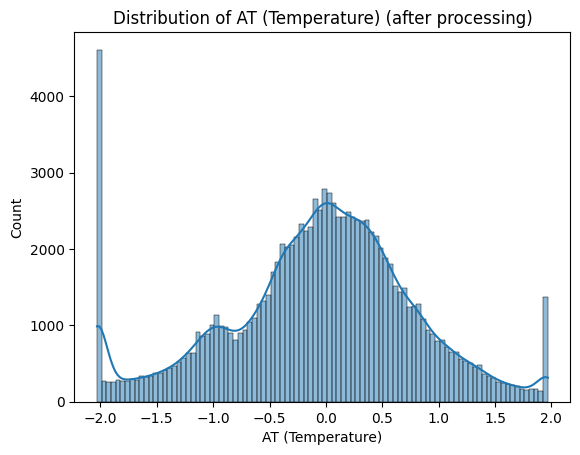

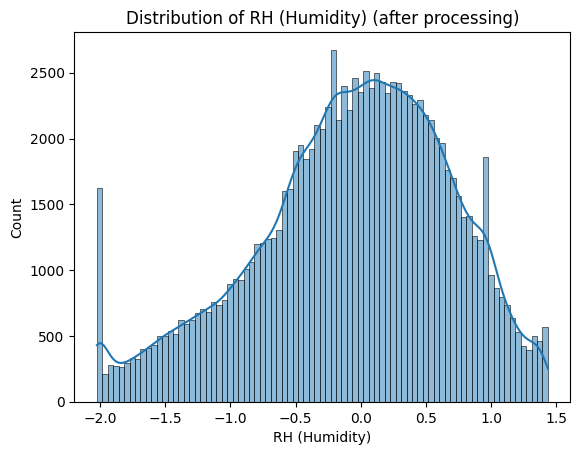

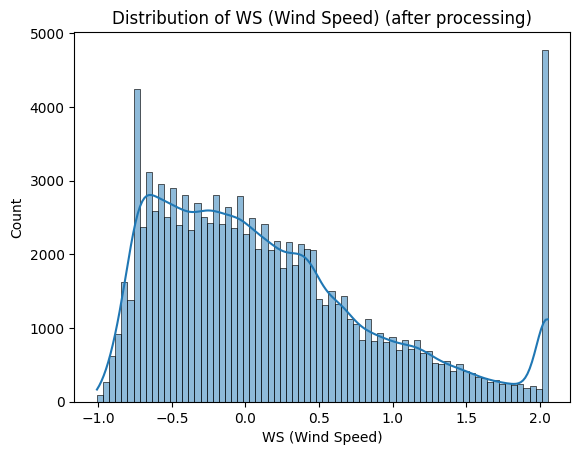

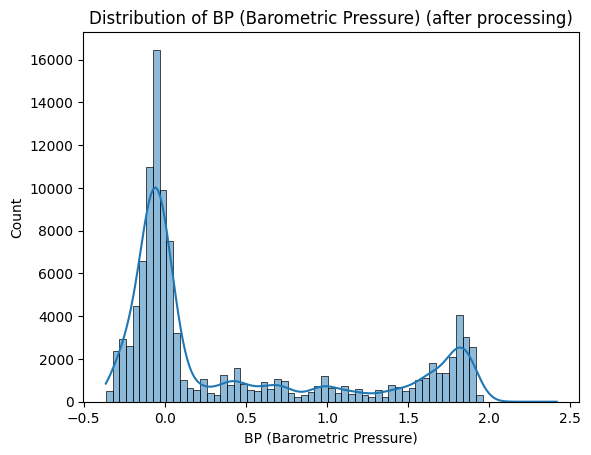

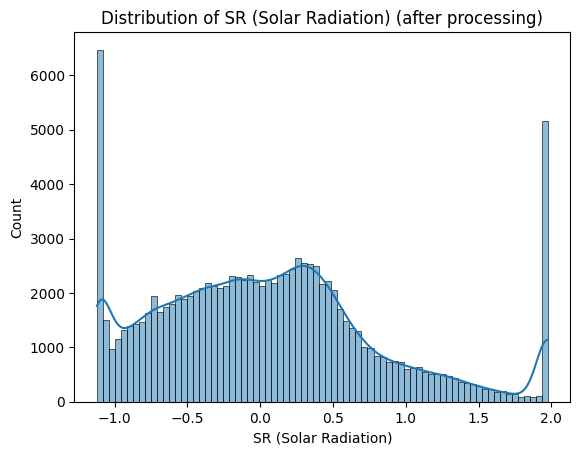

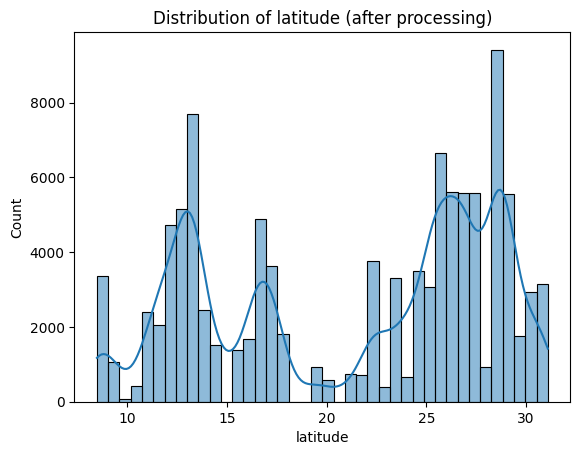

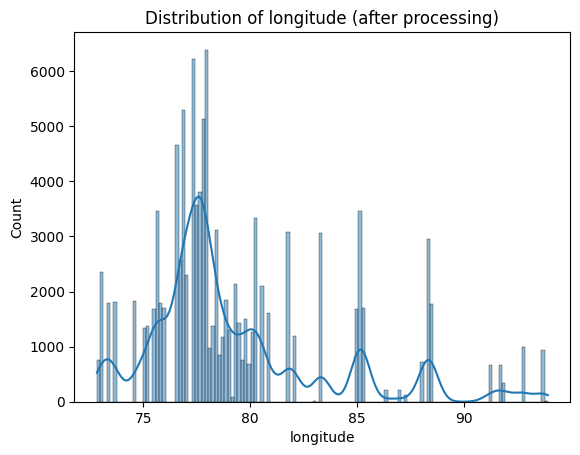

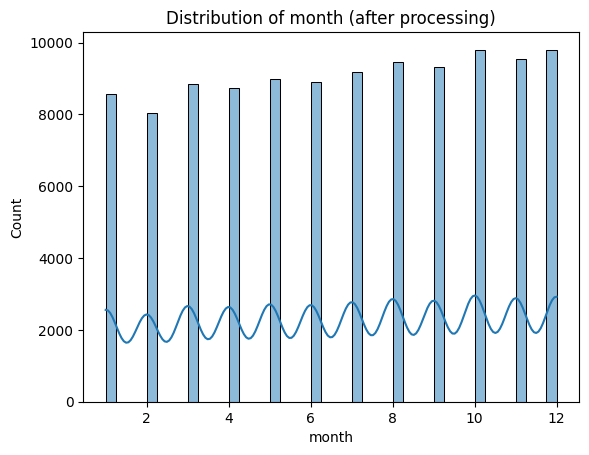

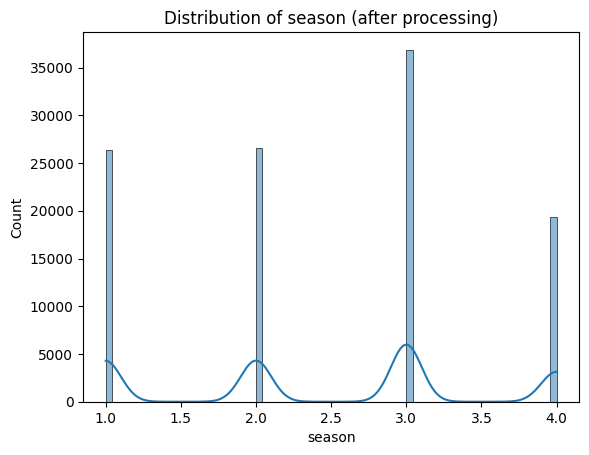

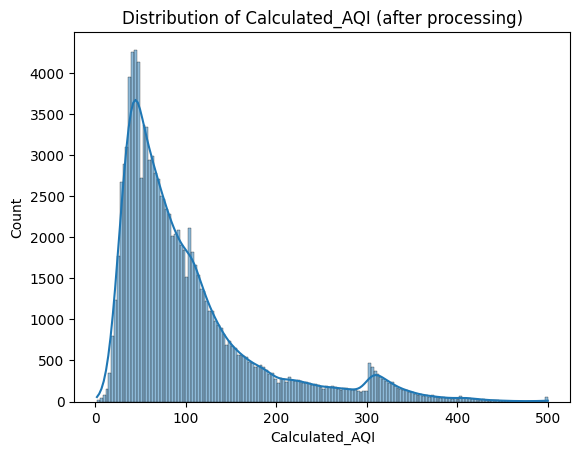

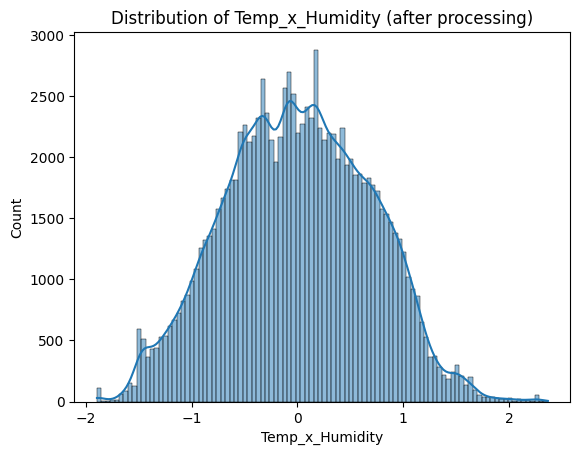

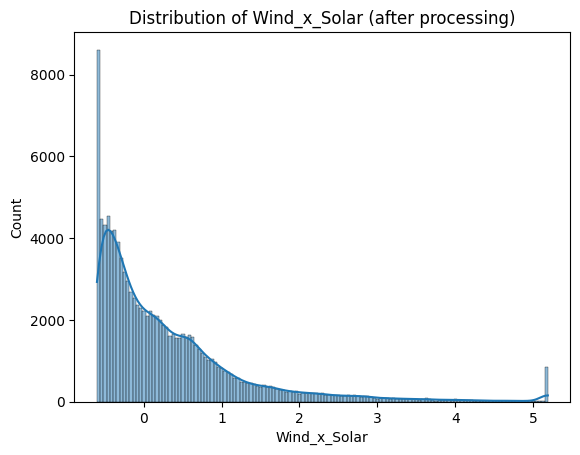

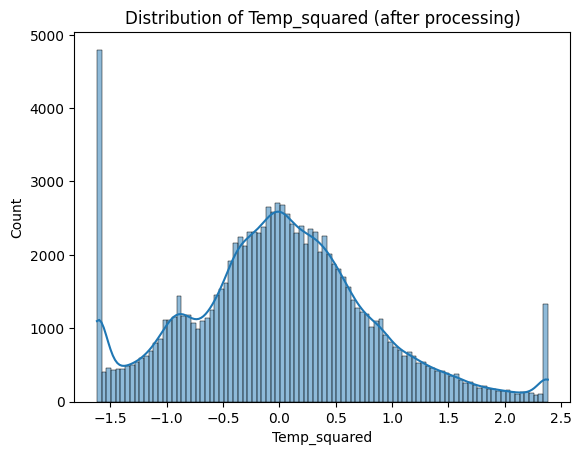

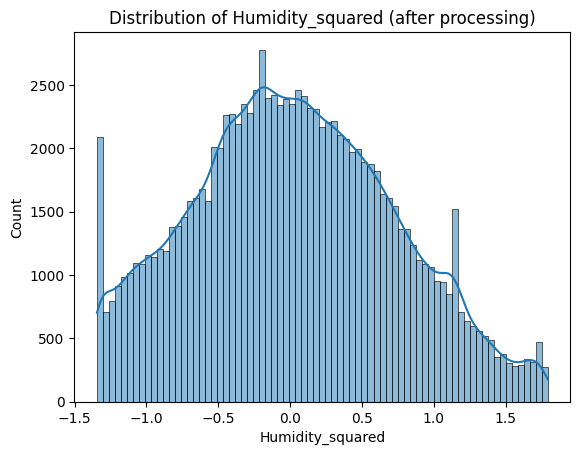

In [145]:
for i in final.columns:
    plt.figure()
    sns.histplot(final[i], kde=True)
    plt.title(f"Distribution of {i} (after processing)")
    plt.show()

### 12b. Boxplots (after processing)

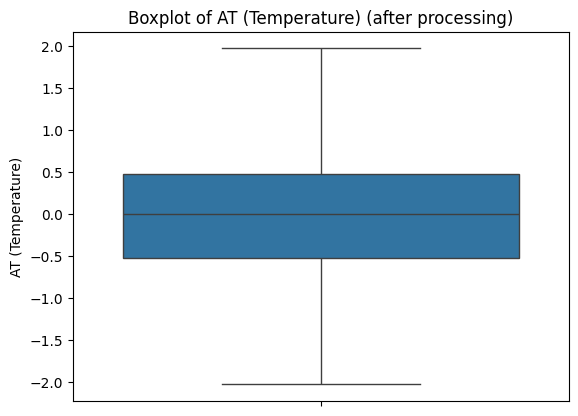

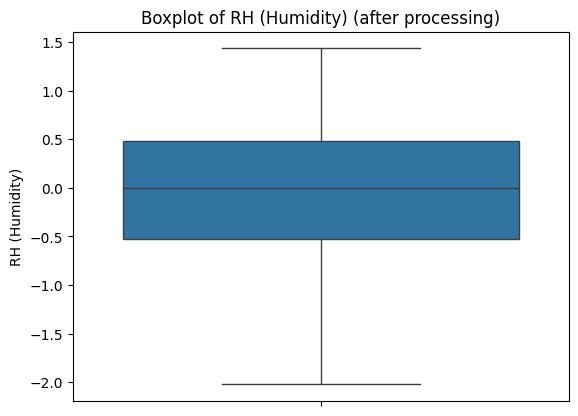

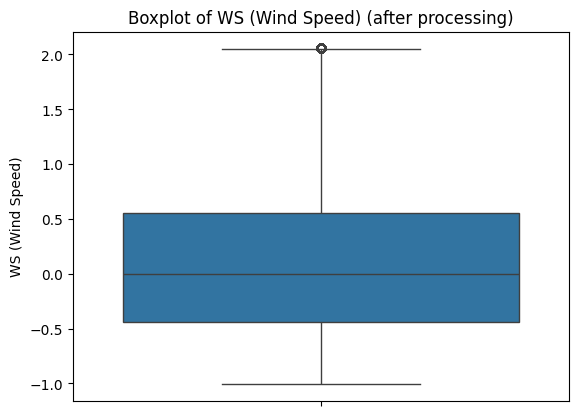

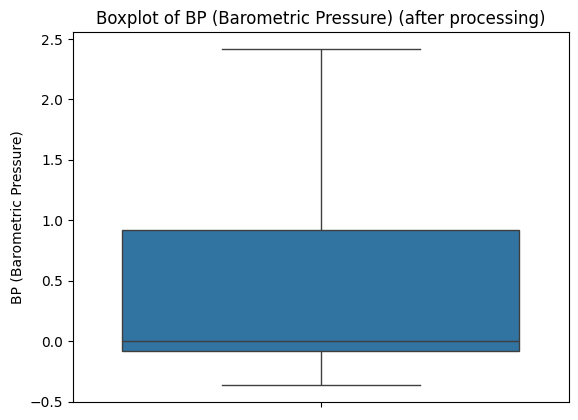

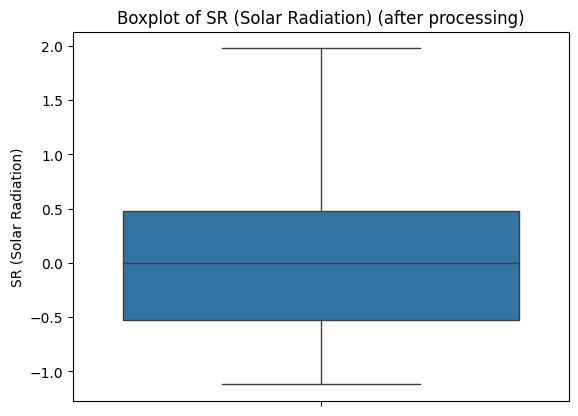

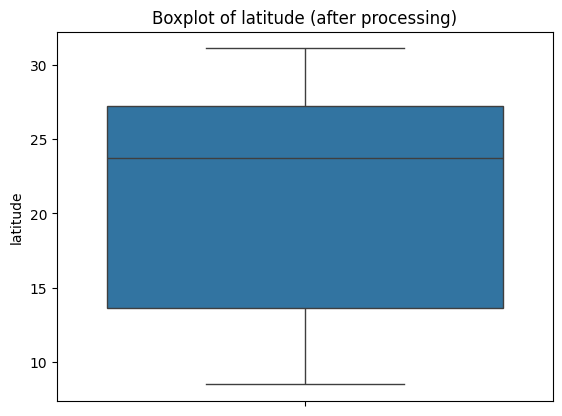

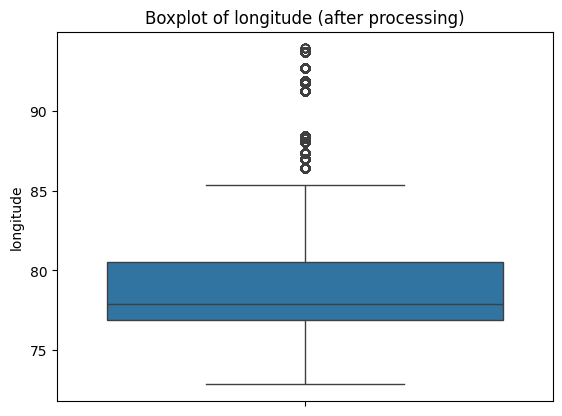

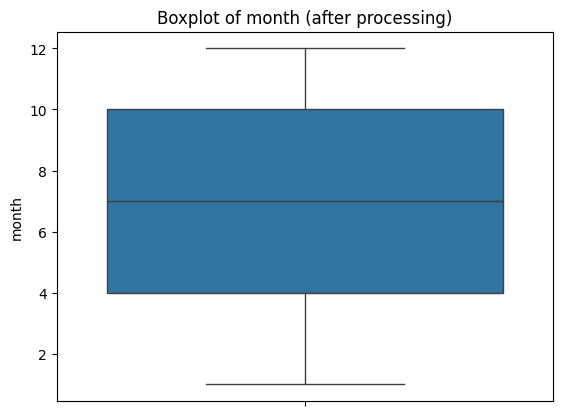

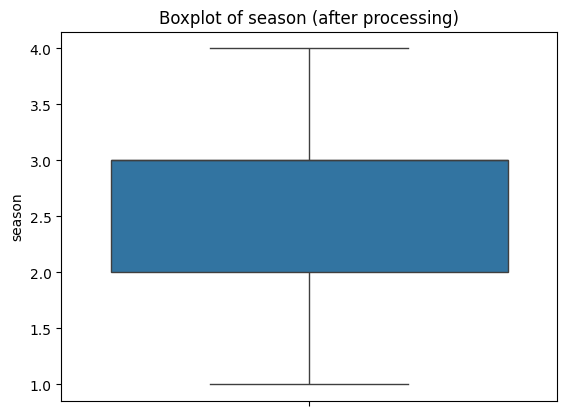

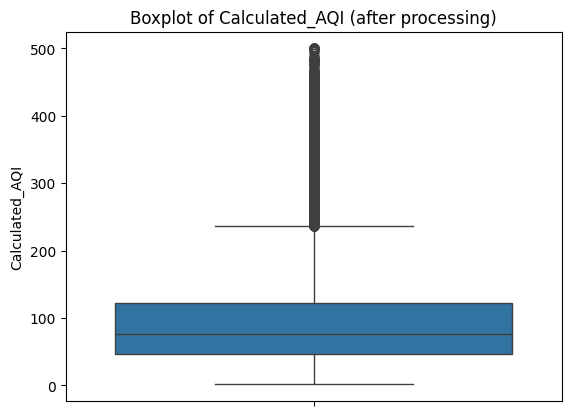

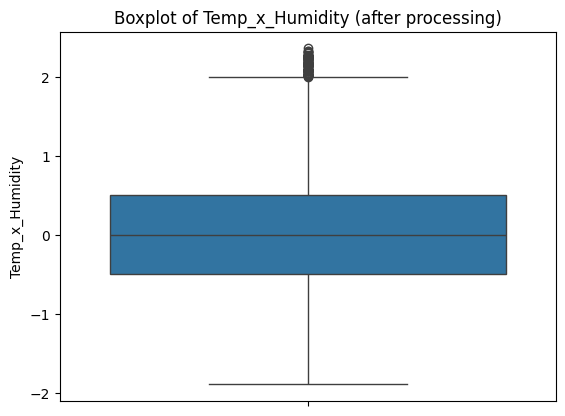

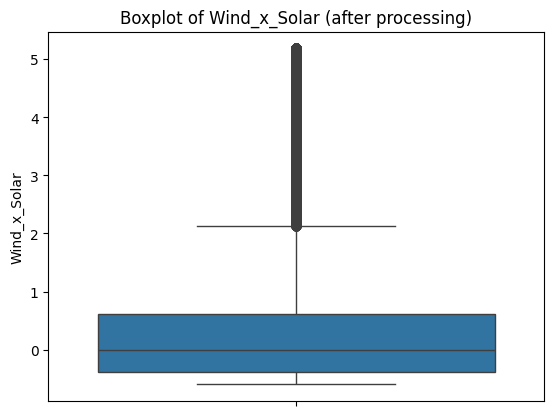

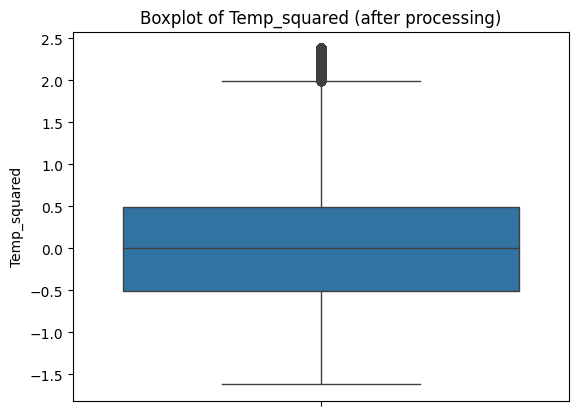

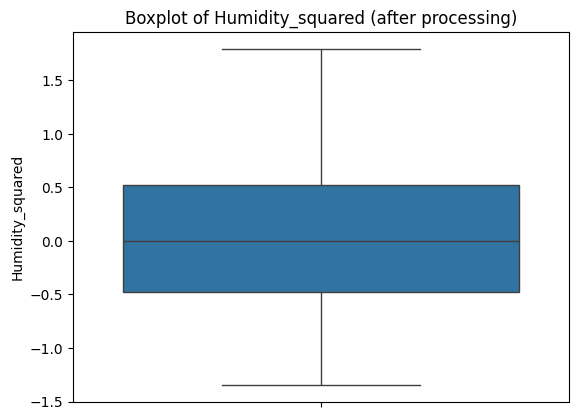

In [146]:
for col in final.columns:
    plt.figure()
    sns.boxplot(y=final[col])
    plt.title(f"Boxplot of {col} (after processing)")
    plt.show()

## 13. Showing Final Dataset

In [147]:
print(f"Rows: {len(final)}")
print(f"Features: AT (Temperature), RH (Humidity), WS (Wind Speed), BP (Barometric Pressure), SR (Solar Radiation), latitude, longitude")
print(f"Target: Calculated_AQI (range {final['Calculated_AQI'].min():.0f}\u2013{final['Calculated_AQI'].max():.0f}, mean {final['Calculated_AQI'].mean():.1f})")

Rows: 109165
Features: AT (Temperature), RH (Humidity), WS (Wind Speed), BP (Barometric Pressure), SR (Solar Radiation), latitude, longitude
Target: Calculated_AQI (range 2–500, mean 101.3)


## 14. Integrating the Linear Regression Model

In [148]:
x = final.drop('Calculated_AQI', axis=1)
y = final['Calculated_AQI']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"\nTrain: {len(x_train):,}  |  Test: {len(x_test):,}")


Train: 87,332  |  Test: 21,833


In [149]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    }

print(f"\n{'='*80}")
print(f"{'MODEL COMPARISON (' + str(len(models)) + ' models)':^80}")
print(f"{'='*80}")

results = {}
for name, model in models.items():
    print(f"\n--- {name} ---")
    print(f"  Training...", end=" ")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print("Done.")
    r2 = r2_score(y_test,y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {"r2": r2, "mape": mape, "rmse": rmse}

    print(f"  R² Score:       {r2:.4f}")
    print(f"  MAPE:           {mape:.4f}")
    print(f"  RMSE:           {rmse:.2f}")



                          MODEL COMPARISON (2 models)                           

--- Linear Regression ---
  Training... Done.
  R² Score:       0.2966
  MAPE:           0.6286
  RMSE:           66.48

--- Random Forest ---
  Training... Done.
  R² Score:       0.7470
  MAPE:           0.3041
  RMSE:           39.87


In [ ]:
# ── 11. Random Forest Hyperparameter Tuning (RandomizedSearch) ──────────────

print(f"\n{'='*80}")
print(f"{'FAST RANDOM FOREST TUNING (RandomizedSearch)':^80}")
print(f"{'='*80}")

# 1. Define the distribution of parameters to test
param_distributions = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10, 15]
}

# 2. Initialize the Randomized Search
print("Running RandomizedSearchCV...")
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=10,            # MAGIC SPEED BUTTON: Only test 10 random combinations!
    cv=3,                 # 3-Fold Cross Validation for speed
    scoring='r2',         # Optimize for the highest R2 score
    random_state=42,      # Ensures reproducible results
    n_jobs=-1             # Use all available CPU cores to process in parallel
)

# 3. Fit the randomized search on the TRAINING data
rf_random.fit(x_train, y_train)

# 4. Extract the absolute best model from the 10 combinations
best_rf_model = rf_random.best_estimator_

print("\n--- Randomized Search Results ---")
print(f"Best Parameters Found: {rf_random.best_params_}")
print(f"Best Cross-Validated R² (Train): {rf_random.best_score_:.4f}")

# 5. Evaluate the winning model on the unseen TEST data
print("\n--- Evaluating Best Model on Test Data ---")
y_pred_tuned = best_rf_model.predict(x_test)

tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_mape = mean_absolute_percentage_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"Test R² Score:   {tuned_r2:.4f}")
print(f"Test MAPE:       {tuned_mape:.4f}")
print(f"Test RMSE:       {tuned_rmse:.2f}")


                  FAST RANDOM FOREST TUNING (RandomizedSearch)                  
Running RandomizedSearchCV (this will finish much faster!)...
